In [55]:
import numpy as np
import time
from scipy.linalg import lu_factor, lu_solve, cholesky, cho_solve
import matplotlib.pyplot as plt

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">LU Decomposition</b>

<p>
The LU decomposition factors a square matrix \(A\) into the product of a lower triangular matrix \(L\) and an upper triangular matrix \(U\):
</p>

$$
A = LU.
$$

<p>
The matrix \(L\) contains the multipliers used during Gaussian elimination and has ones on its diagonal.  
The matrix \(U\) is the upper triangular matrix obtained after eliminating all entries below the pivots.
</p>

<p><b>Structure of the factors</b></p>

$$
L =
\begin{pmatrix}
1      & 0      & \cdots & 0 \\
\ell_{21} & 1      & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
\ell_{n1} & \ell_{n2} & \cdots & 1
\end{pmatrix},
\qquad
U =
\begin{pmatrix}
u_{11} & u_{12} & \cdots & u_{1n} \\
0      & u_{22} & \cdots & u_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
0      & 0      & \cdots & u_{nn}
\end{pmatrix}.
$$

<p><b>Gaussian elimination interpretation</b></p>

<p>
At each elimination step \(k\), the entries below the pivot \(a_{kk}\) are eliminated using multipliers
</p>

$$
\ell_{ik} = \frac{a_{ik}}{a_{kk}}, \qquad i = k+1,\dots,n.
$$

<p>
These multipliers fill the subdiagonal entries of \(L\), while the updated matrix entries form the rows of \(U\).
</p>

    
<p><b>Existence</b></p>    
<p>
 A matrix \(A\) admits an LU decomposition without pivoting if and only if all leading principal minors are nonzero:
</p>


$$
\det(A_{1:k,\,1:k}) \neq 0, \qquad k = 1,\dots,n.
$$


<p>
With pivoting, LU exists for all nonsingular matrices.
</p>
    
    
<p><b>LU with partial pivoting</b></p>

<p>
If a pivot is zero or too small, row swaps are performed to maintain numerical stability.  
This introduces a permutation matrix \(P\), giving the factorization
</p>

$$
PA = LU.
$$

<p>
Here \(P\) records the row exchanges, while the elimination process proceeds as usual.
</p>
    

<p><b>Example</b></p>

<p>
For
</p>

$$
A =
\begin{pmatrix}
2 & 1 \\
4 & 3
\end{pmatrix},
$$

<p>
the multiplier is
</p>

$$
\ell_{21} = \frac{4}{2} = 2,
$$

<p>
leading to
</p>

$$
L =
\begin{pmatrix}
1 & 0 \\
2 & 1
\end{pmatrix},
\qquad
U =
\begin{pmatrix}
2 & 1 \\
0 & 1
\end{pmatrix}.
$$

<p>
Thus \(A = LU\).
</p>

</div>

In [2]:
class LU_nopivot:
    """
    Out-of-place LU decomposition without pivoting.
    Computes A = L U where:
        - L is unit lower triangular (diagonal = 1)
        - U is upper triangular
    """

    def __init__(self, A):
        A = np.array(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("LU decomposition requires a square matrix.")

        self.A = A
        self.n = A.shape[0]
        self.L = None
        self.U = None

    def factor(self):
        """
        Compute L and U out-of-place.
        Raises an error if a zero pivot is encountered.
        """
        n = self.n
        A = self.A

        L = np.eye(n)
        U = A.copy()

        for k in range(n):
            pivot = U[k, k]

            # Existence check - since this is a no pivot
            if abs(pivot) < 1e-14:
                raise ValueError(f"Zero pivot encountered at index {k}. "
                                 "LU without pivoting does not exist.")

            for i in range(k+1, n):
                L[i, k] = U[i, k] / pivot

                
                for j in range(k, n):
                    U[i, j] -= L[i, k] * U[k, j]

        self.L = L
        self.U = U
        return L, U

    def forward_sub(self, b):
        n = self.n
        y = np.zeros(n)

        for i in range(n):
            y[i] = b[i] - np.dot(self.L[i, :i], y[:i])
        return y

    def backward_sub(self, y):
        n = self.n
        x = np.zeros(n)

        for i in reversed(range(n)):
            if abs(self.U[i, i]) < 1e-14:
                raise ValueError("Zero diagonal entry in U during back substitution.")
            x[i] = (y[i] - np.dot(self.U[i, i+1:], x[i+1:])) / self.U[i, i]
        return x

    def solve(self, b):
        if self.L is None or self.U is None:
            self.factor()

        b = np.array(b, dtype=float)

        y = self.forward_sub(b)
        x = self.backward_sub(y)
        return x

In [3]:
def time_lu_nopivot(sizes, repeats=3):
    """
    Times LU_nopivot factor + solve for different matrix sizes.
    """
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            A = np.random.randn(n, n)
            b = np.random.randn(n)

            solver = LU_nopivot(A)

            start = time.perf_counter()
            solver.factor()
            solver.solve(b)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results

In [4]:
sizes = [10, 20, 40, 80, 120]
timings = time_lu_nopivot(sizes)

for n, t in timings.items():
    print(f"{n:4d} x {n:4d}  →  {t:.6f} seconds")

  10 x   10  →  0.000442 seconds
  20 x   20  →  0.002419 seconds
  40 x   40  →  0.017592 seconds
  80 x   80  →  0.135175 seconds
 120 x  120  →  0.447920 seconds


In [5]:
def time_scipy_lu(sizes, repeats=3):
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            A = np.random.randn(n, n)
            b = np.random.randn(n)

            start = time.perf_counter()
            lu, piv = lu_factor(A, overwrite_a=False, check_finite=False)
            x = lu_solve((lu, piv), b, check_finite=False)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results


sizes = [10, 20, 40, 80, 120]
timings = time_scipy_lu(sizes)

for n, t in timings.items():
    print(f"{n:4d} x {n:4d}  →  {t:.6f} seconds")

  10 x   10  →  0.000032 seconds
  20 x   20  →  0.000047 seconds
  40 x   40  →  0.000040 seconds
  80 x   80  →  0.000073 seconds
 120 x  120  →  0.000153 seconds


In [6]:
def time_numpy_solve(sizes, repeats=3):
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            A = np.random.randn(n, n)
            b = np.random.randn(n)

            start = time.perf_counter()
            np.linalg.solve(A, b)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results

sizes = [10, 20, 40, 80, 120]
timings = time_numpy_solve(sizes)

for n, t in timings.items():
    print(f"{n:4d} x {n:4d}  →  {t:.6f} seconds")

  10 x   10  →  0.000025 seconds
  20 x   20  →  0.000132 seconds
  40 x   40  →  0.000474 seconds
  80 x   80  →  0.001059 seconds
 120 x  120  →  0.001635 seconds


In [7]:
sizes = [20, 40, 80, 120, 160]

t_my_lu = time_lu_nopivot(sizes)
t_scipy = time_scipy_lu(sizes)
t_numpy = time_numpy_solve(sizes)

In [8]:
def print_timings(title, timings):
    print(f"\n{title}")
    print("-" * len(title))
    for n, t in timings.items():
        print(f"{n:4d} x {n:4d}  →  {t:.6f} seconds")


print_timings("My LU", t_my_lu)
print_timings("SciPy LU", t_scipy)
print_timings("NumPy solve", t_numpy)


My LU
-----
  20 x   20  →  0.002526 seconds
  40 x   40  →  0.017659 seconds
  80 x   80  →  0.132500 seconds
 120 x  120  →  0.447102 seconds
 160 x  160  →  1.057976 seconds

SciPy LU
--------
  20 x   20  →  0.000018 seconds
  40 x   40  →  0.000032 seconds
  80 x   80  →  0.000072 seconds
 120 x  120  →  0.000153 seconds
 160 x  160  →  0.000250 seconds

NumPy solve
-----------
  20 x   20  →  0.000113 seconds
  40 x   40  →  0.002402 seconds
  80 x   80  →  0.009273 seconds
 120 x  120  →  0.001607 seconds
 160 x  160  →  0.002878 seconds


In [9]:
A = np.array([
    [0, 1],
    [1, 1]
], dtype=float)

b = np.array([1, 2], dtype=float)

try:
    solver = LU_nopivot(A)
    x_my = solver.solve(b)
    print("My LU solution:", x_my)
except Exception as e:
    print("My LU failed:", e)


try:
    lu, piv = lu_factor(A)
    x_scipy = lu_solve((lu, piv), b)
    print("SciPy solution:", x_scipy)
except Exception as e:
    print("SciPy failed:", e)

My LU failed: Zero pivot encountered at index 0. LU without pivoting does not exist.
SciPy solution: [1. 1.]


In [10]:
class LU_optimized:
    def __init__(self, A):
        A = np.array(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("LU decomposition requires a square matrix.")

        self.A = A
        self.n = A.shape[0]
        self.piv = np.arange(self.n)   # permutation vector
        self._factored = False

    def factor(self):
        self._factored = True
        A = self.A
        n = self.n
        piv = self.piv

        for k in range(n):
            p = k + np.argmax(np.abs(A[k:, k]))
            if abs(A[p, k]) < 1e-14:
                raise ValueError("Matrix is singular to working precision.")

            if p != k:
                A[[k, p], :] = A[[p, k], :]
                piv[[k, p]] = piv[[p, k]]

            A[k+1:, k] /= A[k, k]
            A[k+1:, k+1:] -= np.outer(A[k+1:, k], A[k, k+1:])

        return A, piv

    def solve(self, b):
        if not self._factored:
            self.factor()
            
        A = self.A
        piv = self.piv
        n = self.n

        b = np.array(b, dtype=float)
        b = b[piv]   

        for i in range(n):
            b[i+1:] -= A[i+1:, i] * b[i]

        for i in reversed(range(n)):
            b[i] /= A[i, i]
            b[:i] -= A[:i, i] * b[i]

        return b

In [11]:
A = np.array([
    [0, 1],
    [1, 1]
], dtype=float)

b = np.array([1, 2], dtype=float)

try:
    solver = LU_optimized(A)
    x_my = solver.solve(b)
    print("My LU solution:", x_my)
except Exception as e:
    print("My LU failed:", e)

My LU solution: [1. 1.]


In [12]:
def time_lu_optimized(sizes, repeats=3):
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            A = np.random.randn(n, n)
            b = np.random.randn(n)

            solver = LU_optimized(A)

            start = time.perf_counter()
            solver.factor()
            solver.solve(b)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results

In [13]:
sizes = [20, 40, 80, 120, 160]


t_my_lu = time_lu_nopivot(sizes)
t_my_lu_opt = time_lu_optimized(sizes)
t_scipy = time_scipy_lu(sizes)
t_numpy = time_numpy_solve(sizes)


print_timings("My LU (not optimized)", t_my_lu)
print_timings("My LU (optimized)", t_my_lu_opt)
print_timings("SciPy LU", t_scipy)
print_timings("NumPy solve", t_numpy)


My LU (not optimized)
---------------------
  20 x   20  →  0.002574 seconds
  40 x   40  →  0.018048 seconds
  80 x   80  →  0.140249 seconds
 120 x  120  →  0.469813 seconds
 160 x  160  →  1.075144 seconds

My LU (optimized)
-----------------
  20 x   20  →  0.000930 seconds
  40 x   40  →  0.001986 seconds
  80 x   80  →  0.004125 seconds
 120 x  120  →  0.007138 seconds
 160 x  160  →  0.010595 seconds

SciPy LU
--------
  20 x   20  →  0.000025 seconds
  40 x   40  →  0.000030 seconds
  80 x   80  →  0.000068 seconds
 120 x  120  →  0.000143 seconds
 160 x  160  →  0.000224 seconds

NumPy solve
-----------
  20 x   20  →  0.000115 seconds
  40 x   40  →  0.000380 seconds
  80 x   80  →  0.029160 seconds
 120 x  120  →  0.001763 seconds
 160 x  160  →  0.002212 seconds


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">SciPy Is Much Faster</b>

<p>
The large performance gap between our pure Python implementation and SciPy’s 
<code>lu_factor</code> is expected. SciPy does not perform the factorization in Python: 
it calls the LAPACK routine <code>dgetrf</code>, which is written in optimized Fortran 
and built on top of high‑performance BLAS libraries.
</p>

<p>
These libraries use blocked algorithms, meaning the matrix is processed in 
square blocks rather than one column at a time. This allows most of the work to be 
carried out by BLAS‑3 matrix–matrix operations, which are heavily optimized for modern 
hardware (cache locality, SIMD vectorization, and multi‑threading).
</p>

<p>
In contrast, a pure Python implementation, even when vectorized with NumPy, still performs 
the main elimination loop in Python and cannot exploit these low‑level optimizations. 
This difference in execution model explains why SciPy achieves much higher performance.
</p>

</div>

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Cholesky Decomposition</b>

<p>
The Cholesky decomposition is a specialized factorization for symmetric positive definite 
matrices. For such a matrix \(A\), the decomposition writes
</p>

$$
A = LL^\top,
$$

<p>
where \(L\) is a lower triangular matrix with positive diagonal entries.  
This factorization is unique and is often preferred over LU when applicable, since it 
requires roughly half the work and is numerically very stable.
</p>

<p><b>Structure of the factor</b></p>

$$
L =
\begin{pmatrix}
\ell_{11} & 0      & \cdots & 0 \\
\ell_{21} & \ell_{22} & \cdots & 0 \\
\vdots    & \vdots    & \ddots & \vdots \\
\ell_{n1} & \ell_{n2} & \cdots & \ell_{nn}
\end{pmatrix}.
$$

<p><b>Computation</b></p>

<p>
The entries of \(L\) are obtained by processing one row at a time:
</p>

$$
\ell_{kk} = \sqrt{\,a_{kk} - \sum_{j=1}^{k-1} \ell_{kj}^2\,},
$$

$$
\ell_{ik} = \frac{1}{\ell_{kk}}
\left(a_{ik} - \sum_{j=1}^{k-1} \ell_{ij}\ell_{kj}\right),
\qquad i = k+1,\dots,n.
$$

<p>
Because the matrix is symmetric, only the lower triangular part needs to be computed.
</p>

<p><b>Conditions for existence</b></p>

<p>
A Cholesky factorization exists if and only if \(A\) is symmetric positive definite.  
This ensures that all diagonal pivots remain positive, allowing the square roots to be taken.
</p>

<p><b>Example</b></p>

<p>
For
</p>

$$
A =
\begin{pmatrix}
4 & 2 \\
2 & 3
\end{pmatrix},
$$

<p>
the factor is
</p>

$$
L =
\begin{pmatrix}
2 & 0 \\
1 & \sqrt{2}
\end{pmatrix},
\qquad
LL^\top =
\begin{pmatrix}
4 & 2 \\
2 & 3
\end{pmatrix}.
$$

</div>

In [14]:
def is_symmetric(A, tol=1e-12):
    n = len(A)
    for i in range(n):
        for j in range(i+1, n):   
            if abs(A[i][j] - A[j][i]) > tol:
                return False
    return True

In [15]:
class Cholesky:
    def __init__(self, A):
        A = np.array(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("Cholesky decomposition requires a square matrix.")
        
        if not is_symmetric(A):
            raise ValueError("Matrix must be symmetric.")

        self.A = A
        self.n = A.shape[0]
        self._factored = False
        
    def factor(self):
        A = self.A
        n = self.n
        
        self._factored = True

        for k in range(n):
            s = 0.0
            for j in range(k):
                s += A[k][j] * A[k][j]

            val = A[k][k] - s
            if val <= 0:
                raise ValueError("Matrix is not positive definite.")
            A[k][k] = val**0.5

            # column below
            for i in range(k+1, n):
                s = 0.0
                for j in range(k):
                    s += A[i][j] * A[k][j]

                A[i][k] = (A[i][k] - s) / A[k][k]
        for i in range(n):
            for j in range(i+1, n):
                A[i][j] = 0.0
                
        return A  

    def solve(self, b):
        if not self._factored:
            self.factor()

        A = self.A
        n = self.n
        b = list(map(float, b))


        for i in range(n):
            s = 0.0
            for j in range(i):
                s += A[i][j] * b[j]
            b[i] = (b[i] - s) / A[i][i]


        for i in reversed(range(n)):
            s = 0.0
            for j in range(i+1, n):
                s += A[j][i] * b[j]
            b[i] = (b[i] - s) / A[i][i]

        return b

In [16]:
def time_cholesky_sizes(sizes, repeats=3):
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            # generate SPD matrix
            A = np.random.randn(n, n)
            A = A @ A.T + 1e-6 * np.eye(n)

            b = np.random.randn(n)

            solver = Cholesky(A)

            start = time.perf_counter()
            solver.factor()
            solver.solve(b)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results

In [17]:
def time_scipy_cholesky_solve(sizes, repeats=3):
    results = {}

    for n in sizes:
        best = float("inf")

        for _ in range(repeats):
            # SPD matrix
            A = np.random.randn(n, n)
            A = A @ A.T + 1e-6 * np.eye(n)

            b = np.random.randn(n)

            start = time.perf_counter()
            L = cholesky(A, lower=True, overwrite_a=False, check_finite=False)
            x = cho_solve((L, True), b)
            end = time.perf_counter()

            best = min(best, end - start)

        results[n] = best

    return results

In [21]:
sizes = [100,200,300]

t_my = time_cholesky_sizes(sizes)
t_scipy = time_scipy_cholesky_solve(sizes)

print_timings("My Cholesky", t_my)
print_timings("SciPy Cholesky", t_scipy)


My Cholesky
-----------
 100 x  100  →  0.144881 seconds
 200 x  200  →  1.092899 seconds
 300 x  300  →  3.634367 seconds

SciPy Cholesky
--------------
 100 x  100  →  0.000129 seconds
 200 x  200  →  0.000412 seconds
 300 x  300  →  0.001136 seconds


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Generating Correlated Monte Carlo Samples</b>

<p>
In many quantitative finance applications, we need to simulate random variables that are 
<strong>not independent</strong> but exhibit a prescribed correlation structure.
</p>

<p>
To achieve this, we begin with a target covariance matrix \( \Sigma \) and use the 
<strong>Cholesky decomposition</strong> to construct a linear transformation that maps 
independent standard normal samples into correlated ones.
</p>

<p><b>Core idea</b></p>

<p>
If \( \Sigma \) is symmetric positive definite, its Cholesky factorization gives
</p>

$$
\Sigma = LL^\top,
$$

<p>
where \(L\) is lower triangular.  
If we draw independent samples \( z \sim N(0, I) \), then the transformed samples
</p>

$$
x = Lz
$$

<p>
satisfy
</p>

$$
\mathbb{E}[xx^\top] = \Sigma,
$$

<p>
meaning they have exactly the covariance structure we want.
</p>

<p><b>Monte Carlo workflow</b></p>

<ol>
  <li>Specify a covariance matrix \( \Sigma \).</li>
  <li>Compute its Cholesky factor \(L\).</li>
  <li>Generate many independent samples \(z\).</li>
  <li>Transform them via \(x = Lz\) to obtain correlated samples.</li>
  <li>Compute the empirical covariance of the simulated data.</li>
  <li>Compare and visualize the match with the target covariance.</li>
</ol>

<p>
This procedure is fundamental in pricing, risk management, and scenario generation.  
In the following cells, I implement each step and verify that the Monte Carlo samples 
faithfully reproduce the desired covariance structure.
</p>

</div>

In [26]:
Sigma = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.4],
    [0.3, 0.4, 1.0]
])

chol = Cholesky(Sigma.copy())
L = chol.factor()

L

array([[1.        , 0.        , 0.        ],
       [0.8       , 0.6       , 0.        ],
       [0.3       , 0.26666667, 0.91590878]])

In [33]:
def sample_covariance(X):
    d, N = X.shape
    mean = np.sum(X, axis=1, keepdims=True) / N   # shape (d, 1)
    X_centered = X - mean
    
    return (X_centered @ X_centered.T) / (N - 1)

In [50]:
n_samples = 5000000

Z = np.random.randn(3, n_samples)

# correlated samples: X = L Z
X = L @ Z
empirical_cov = sample_covariance(X)
empirical_cov

array([[1.00104509, 0.80034034, 0.29964851],
       [0.80034034, 0.999699  , 0.39922043],
       [0.29964851, 0.39922043, 0.99935658]])

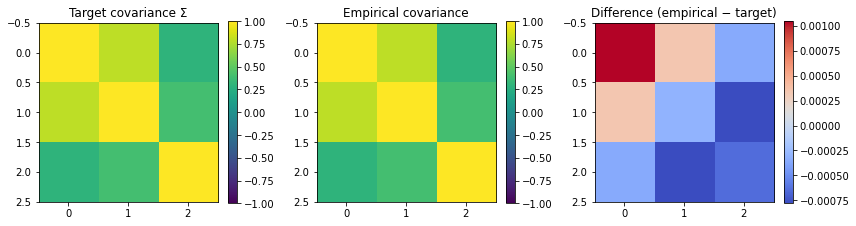

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(Sigma, cmap="viridis", vmin=-1, vmax=1)
axes[0].set_title("Target covariance Σ")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(empirical_cov, cmap="viridis", vmin=-1, vmax=1)
axes[1].set_title("Empirical covariance")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(empirical_cov - Sigma, cmap="coolwarm")
axes[2].set_title("Difference (empirical − target)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [52]:
print("Target Σ:\n", Sigma)
print("Empirical Σ:\n", empirical_cov)
print("Difference:\n", empirical_cov - Sigma)

Target Σ:
 [[1.  0.8 0.3]
 [0.8 1.  0.4]
 [0.3 0.4 1. ]]
Empirical Σ:
 [[1.00104509 0.80034034 0.29964851]
 [0.80034034 0.999699   0.39922043]
 [0.29964851 0.39922043 0.99935658]]
Difference:
 [[ 0.00104509  0.00034034 -0.00035149]
 [ 0.00034034 -0.000301   -0.00077957]
 [-0.00035149 -0.00077957 -0.00064342]]


In [53]:
with np.errstate(divide='ignore', invalid='ignore'):
    pct_error = 100 * (empirical_cov - Sigma) / Sigma
    pct_error = np.where(Sigma == 0, 0, pct_error)
    
print("\nPercentage error (%):\n", pct_error)

max_pct_error = np.max(np.abs(pct_error))
print("Maximum percentage error:", max_pct_error)


Percentage error (%):
 [[ 0.1045093   0.04254267 -0.11716489]
 [ 0.04254267 -0.03010047 -0.1948916 ]
 [-0.11716489 -0.1948916  -0.0643416 ]]
Maximum percentage error: 0.19489159582662674
